# Event Classification using LLMs

In this Notebook we classify events into predefined categories using a Large Language Model (LLM). The classification is based on the event descriptions provided in the initial set. We also add geographical locations to the events.

## Check the original event json

In [ ]:
import json

with open("event_jsons/dict_wiki_timelines5_geo_country_event.json", encoding="utf8") as f:
    content = json.load(f)

content

{'2001': [{'text': 'Wikipedia is launched.',
   'link': [['/wiki/January_15', 'January 15'],
    ['/wiki/Wikipedia', 'Wikipedia']],
   'date': ['2001-01-15 00:00:00', '2001-01-15 23:59:59'],
   'geo': ['United States'],
   'country': ['United States'],
   'events': [['launched', 'processstart']],
   'event_type': ['proecess']},
  {'text': 'President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.',
   'link': [['/wiki/Joseph_Estrada', 'Joseph Estrada'],
    ['/wiki/Philippines', 'Philippines'],
    ['/wiki/Second_EDSA_Revolution', 'Second EDSA Revolution']],
   'date': ['2001-01-20 00:00:00', '2001-01-20 23:59:59'],
   'geo': ['Philippines'],
   'country': ['Philippines'],
   'events': [['ousted', 'changeofleadership'],
    ['Revolution', 'changeofleadership']],
   'event_type': ['personnel', 'personnel']},
  {'text': 'George W. Bush is inaugurated as President of the United States.',
   'link': [['/wiki/George_W._Bush', 'George W. Bush'],
    ['/wiki/Preside

In [4]:
# print the text of each event in content
counter = 0
for year in content:
    for event in content[year]:
        print(event["text"].replace("\n", " ").strip())
        counter += 1

print(f"\n total of events: {counter}")

Wikipedia is launched.
President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.
George W. Bush is inaugurated as President of the United States.
An earthquake strikes Gujarat, India, on Republic Day, resulting in more than 20,000 deaths.
Twenty tourists are abducted by the Abu Sayyaf Group terrorists from a popular island resort in the Philippines.
Eleven members of the royal family of Nepal, including the king and queen, are killed by Crown Prince Dipendra, who wounds himself and dies three days later.
Nineteen Al-Qaeda terrorists hijack four planes, crashing two into the twin towers of the World Trade Center in New York City, the third plane into the Pentagon in Washington, DC, while the fourth plane is downed on the outskirts of Stonycreek Township, Pennsylvania. 2,996 people, including 2,977 victims and 19 hijackers, die in the attacks.
The United States invades Afghanistan and topples the Taliban regime, resulting in a long-term war.
Steve Jobs introduc

## LLM set up
Create a .env file in this directory and set up you OPENAI_API_KEY.

In [110]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv("../.env")

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

client = OpenAI()

## Adding event categories

In [ ]:
class_sys_prompt = """You are going to be prompted with an event from the 21st century that looks like this:
        
        "The Euro enters circulation."
        
         Your task is to assign it the correct category. The classification is 3-level and it should be as follows:
        
        - POLITICAL
            - leadership changes
                - elections
                - power transfers
                - leader deaths or assassinations
                - royale family events
                - coup d'etat
            - wars and armed conflicts
                - inter state wars
                - civil wars
                - border conflicts
                - terrorist attacks
                - military escalations
                - peace agreements
            - economy
                - Recessions & Crises
                - Trade Agreements & Blocs
                - Financial Scandals
                - Currency & Monetary Changes
            - climate and environment policies
                - agreements 
                - reports
                - conference
            - legal milestones
                - constitutions
                - new legislations
                - others
            - social movements
                - Protests and Riot-triggering events
                - revolutions and uprisings
                - Ethnic or religious tensions escalating
            - diplomatic relations
                - international agreements
                - countries joining organizations and blocs
                - meetings (important meetings from leaders from different countries)
        - NON POLITICAL
            - non political disasters and crisis
                - natural disasters and environmental events
                - health crisis and pandemics
                - other disasters or tragedies
            - technology or science breakthroughs
                - Space Exploration & Astronomy
                - Medical & Biological Discoveries
                - disruptive technologies
                - Consumer Tech Milestones
                - other inventions and discoveries
            - cultural events and influences
                - Major Sports & Arts Events (olympics, concerts)
                - Iconic Deaths
                - Iconic Births
                - artistic and cultural releases (relevant or ifnuential music albums, moovies or boooks)
                - Internet and social network trends
            - corporate and market
                - Founding of major companies
                - Bankruptcy or scandal of influential firms
                - Mergers and acquisitions with global impact
                
        For instance, you could classify "The Euro enters circulation." as political.economy.currency_&_monetary_changes

        Many events may fall in more than one different categories. For example trade agreements may be considered as economy or diplomatic_relations event. Assign ALL possible classes that fit the event with the correct format:
         
        Example:  political.economy.trade_agreements, political.diplomatic_relations.international_agreements"""

In [ ]:
def classify_event(event,client=client,sys_prompt=class_sys_prompt, model="gpt-4.1"):
    
    response = client.responses.create(
    model=model,
    instructions=sys_prompt,
    input=event)

    print(response.output_text)
    return response.output_text

def process_json(event):
    #quitar geo, country, events
    print(event)
    event.pop('geo', None)
    event.pop('country', None)
    event.pop('events', None)

    event["event_type"] = classify_event(event['text']).split(",")

    print(event)
    return event

new_events = {str(k):[] for k in range(2001,2024)}

for year in content:
    for event in content[year]:
        print(event['text'])
        event = process_json(event)
        new_events[year].append(event)

In [ ]:
with open("event_jsons/new_events.json", mode="w", encoding="utf8") as f:
    json.dump(new_events,f,indent=4)

## Detecting geographical regions in events

Another prompt for geographical locations.

In [1]:
geo_sys_prompt = """
    You will receive a text message. Extract geographical locations and regions mentioned or implied in the following text. Specifically you should search 
    ONLY for this type of locations:
    
    - Countries
    - Continents
    - Economic and Geographical organizations or spaces such as the European Union (for example countries with free trade among the,)
    
    If the location is implicit, infer it based on context. 
    
    Some sentences may not contain any locations. In that case, just return nothing. PLease give your answer in the format provided in the examples
    
    Example:
    A hurricane strikes The Southern islands of Japan.
    ["Japan"]

    New company is launched
    []

    New Mayor Elections at the capital of Spain, Madrid
    ["Spain"]

    The border conflict among Israel and Palestina continues
    ["Israel","Palestina"]

    Trumps taxes are afecting most countries from Asia, specially countries in the APEC
    ["Asia","Asia-Pacific Economic Cooperation"]

    """

In [76]:
def extract_locations(event,client=client,sys_prompt=geo_sys_prompt, model="gpt-4.1"):
    
    response = client.responses.create(
    model=model,
    instructions=sys_prompt,
    input=event)

    print(response.output_text)
    return response.output_text


new_events = {str(k):[] for k in range(2001,2024)}

for year in content:
    for event in content[year]:
        print(event['text'])
        event = process_json(event)
        locations = extract_locations(event['text'])
        event["geo"]=json.loads(locations)
        new_events[year].append(event)

Wikipedia is launched.
{'text': 'Wikipedia is launched.', 'link': [['/wiki/January_15', 'January 15'], ['/wiki/Wikipedia', 'Wikipedia']], 'date': ['2001-01-15 00:00:00', '2001-01-15 23:59:59'], 'event_type': ['non_political.technology_or_science_breakthroughs.other_inventions_and_discoveries'], 'geo': '[]'}
non_political.technology_or_science_breakthroughs.disruptive_technologies, non_political.cultural_events_and_influences.internet_and_social_network_trends
{'text': 'Wikipedia is launched.', 'link': [['/wiki/January_15', 'January 15'], ['/wiki/Wikipedia', 'Wikipedia']], 'date': ['2001-01-15 00:00:00', '2001-01-15 23:59:59'], 'event_type': ['non_political.technology_or_science_breakthroughs.disruptive_technologies', ' non_political.cultural_events_and_influences.internet_and_social_network_trends']}
[]
President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.
{'text': 'President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.', 'li

In [ ]:
with open("event_jsons/new_events.json", mode="w", encoding="utf8") as f:
    json.dump(new_events,f,indent=4)

## Some Stats

In [ ]:
# Uncomment to load file and skip event classification and geo extraction
# with open("event_jsons/new_events.json", mode="r", encoding="utf8") as f:
#     new_events = json.load(f)

In [ ]:
def extract_geographical_locations(data):
    geo_locations = []

    for year_events in data.values():
        for event in year_events:
            geo_field = event.get("geo", "[]")
            # convert stringified list to actual list
            if isinstance(geo_field, str):
                geo_field = json.loads(geo_field)
            geo_locations.extend(geo_field)

    return geo_locations

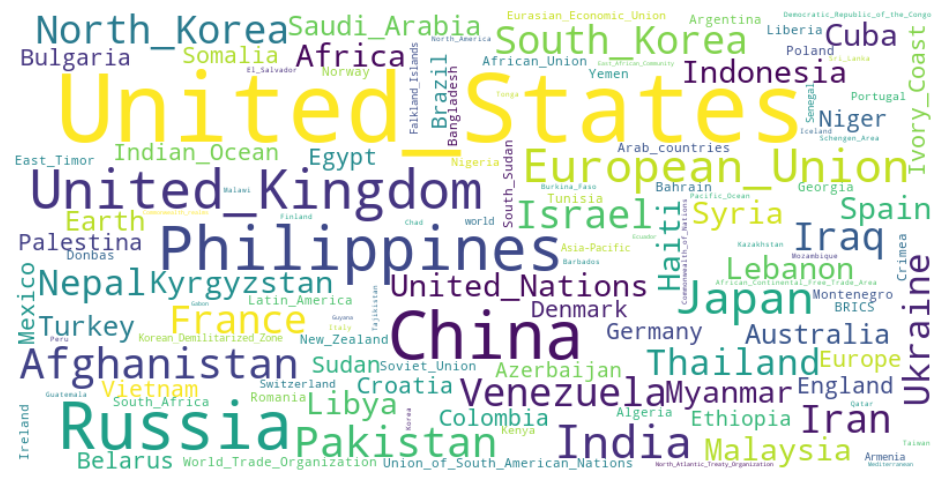

In [80]:
# location wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

def create_wordcloud(terms):
    processed_terms = [term.replace(" ", "_") for term in terms]
    term_freq = Counter(processed_terms)
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(term_freq)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

locations = extract_geographical_locations(new_events)
create_wordcloud(locations)

In [81]:
# events and categories
def extract_categories(data):
    categories = []

    for year_events in data.values():
        for event in year_events:
            field = event.get("event_type", "[]")
            if isinstance(field, str):
                field = json.loads(field)
            categories.extend(field)

    return categories

extract_categories(new_events)

['non_political.technology_or_science_breakthroughs.disruptive_technologies',
 ' non_political.cultural_events_and_influences.internet_and_social_network_trends',
 'political.leadership_changes.power_transfers',
 ' political.social_movements.revolutions_and_uprisings',
 'political.leadership_changes.elections',
 ' political.leadership_changes.power_transfers',
 'non_political.non_political_disasters_and_crisis.natural_disasters_and_environmental_events',
 'political.wars_and_armed_conflicts.terrorist_attacks',
 ' non_political.non_political_disasters_and_crisis.other_disasters_or_tragedies',
 'political.leadership_changes.leader_deaths_or_assassinations',
 ' political.leadership_changes.power_transfers',
 'political.wars_and_armed_conflicts.terrorist_attacks',
 'political.wars_and_armed_conflicts.inter_state_wars',
 ' political.wars_and_armed_conflicts.power_transfers',
 'non_political.technology_or_science_breakthroughs.consumer_tech_milestones',
 'non_political.non_political_disaster

<Axes: >

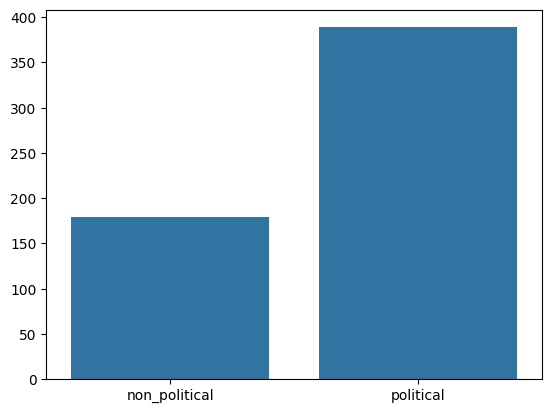

In [96]:
import seaborn as sns

categories = extract_categories(new_events)

split_cats = [cat.strip().split('.') for cat in categories]
class_1 = [lvl1 for lvl1, _, _ in split_cats]
class_2 = [lvl2 for _, lvl2, _ in split_cats]
class_3 = [lvl3 for _, _, lvl3 in split_cats]

class_1_counts = Counter(class_1)
class_2_counts = Counter(class_2)
class_3_counts = Counter(class_3)

sns.barplot(class_1_counts)


<Axes: >

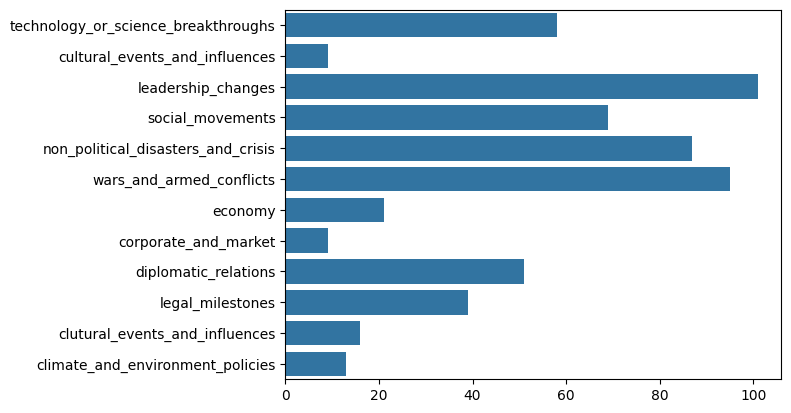

In [97]:
sns.barplot(class_2_counts, orient="h")

<Axes: >

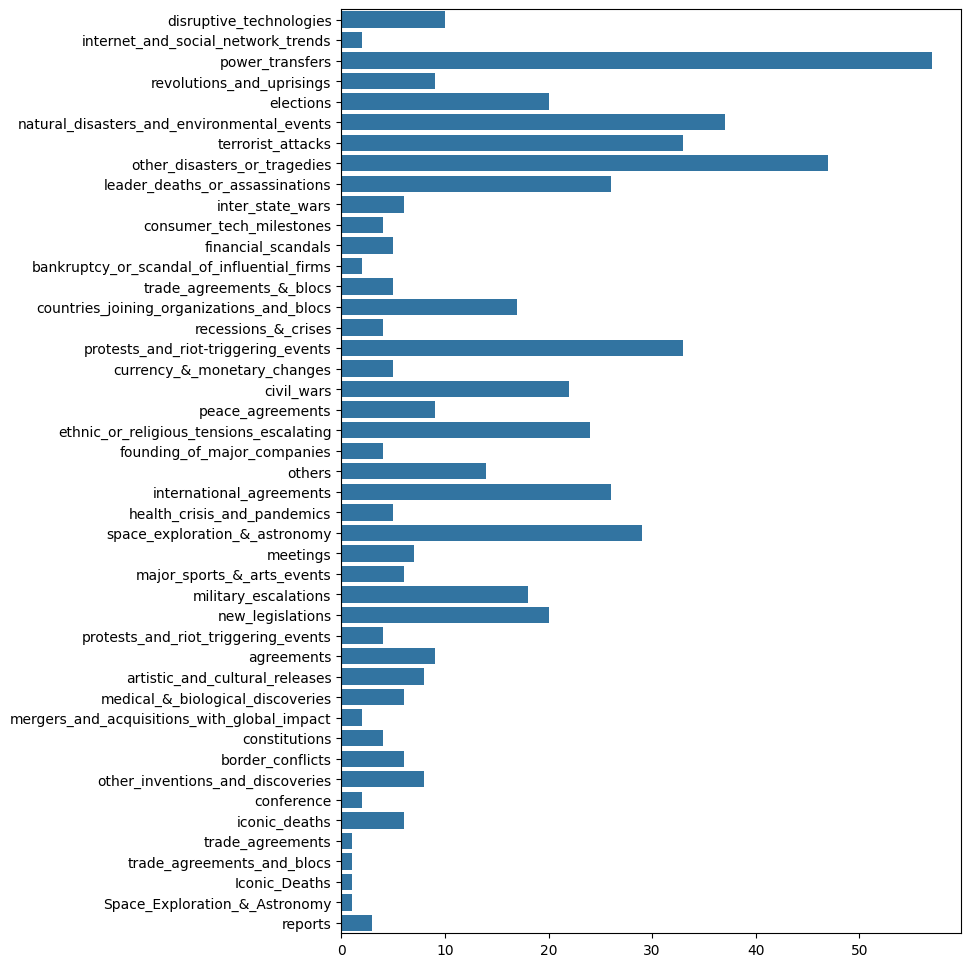

In [98]:
plt.figure(figsize=(8, 12))
sns.barplot(class_3_counts, orient="h")

In [ ]:

parts_list = [cat.strip().split('.', maxsplit=2) for cat in categories]
bad = [categories[i] for i, parts in enumerate(parts_list) if len(parts) != 3]

print(f"Found {len(bad)} entries without a 3-level classification:\n")
for entry in bad:
    print(repr(entry))


Found 0 entries without a 3-level classification:



## Correcting the classification
We will use this as a guide for adjusting the current taxonomy, adding new event types.

In [ ]:
correct_prompt = """You are going to receive a list of historical events from the 21st century in the following format:

Event: <Brief text describing the event took place>
Category: <a list of the categories assigned to the event, following this classification:

- POLITICAL
            - leadership changes
                - elections
                - power transfers
                - leader deaths or assassinations
            - wars and armed conflicts
                - inter state wars
                - civil wars
                - border conflicts
                - terrorist attacks
                - military escalations
                - peace agreements
            - economy
                - Recessions & Crises
                - Trade Agreements & Blocs
                - Financial Scandals
                - Currency & Monetary Changes
            - climate and environment policies
                - agreements 
                - reports
                - conference
            - legal milestones
                - constitutions
                - new legislations
                - others
            - social movements
                - Protests and Riot-triggering events
                - revolutions and uprisings
                - Ethnic or religious tensions escalating
            - diplomatic relations
                - international agreements
                - countries joining organizations and blocs
                - meetings (important meetings from leaders from different countries)
        - NON POLITICAL
            - non political disasters and crisis
                - natural disasters and environmental events
                - health crisis and pandemics
                - other disasters or tragedies
            - technology or science breakthroughs
                - Space Exploration & Astronomy
                - Medical & Biological Discoveries
                - disruptive technologies
                - Consumer Tech Milestones
                - other inventions and discoveries
            - cultural events and influences
                - Major Sports & Arts Events (olympics, concerts)
                - Iconic Deaths
                - artistic and cultural releases (relevant or ifnuential music albums, moovies or boooks)
                - Internet and social network trends
            - corporate and market
                - Founding of major companies
                - Bankruptcy or scandal of influential firms
                - Mergers and acquisitions with global impact>

For the event, you should return a confidence value from 0 to 1 that reflects how good is the classification.
 0 means the geo or the category field dont capture very well the essence of the event, and thus, another category might be needed. 1 means the category captures perfectly the esence of the event.

 Give your answer in this json format:
 {"confidence": <number>
 "reasoning": <your explanations>}
"""

In [104]:
def extract_categories(data):
    categories = []

    for year_events in data.values():
        for event in year_events:
            field = event.get("event_type", "[]")
            if isinstance(field, str):
                field = json.loads(field)
            categories.append({"Event":event["text"],
                               "Categories":field})

    return categories

user_msg = extract_categories(new_events)

In [108]:
user_msg

[{'Event': 'Wikipedia is launched.',
  'Categories': ['non_political.technology_or_science_breakthroughs.disruptive_technologies',
   ' non_political.cultural_events_and_influences.internet_and_social_network_trends']},
 {'Event': 'President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.',
  'Categories': ['political.leadership_changes.power_transfers',
   ' political.social_movements.revolutions_and_uprisings']},
 {'Event': 'George W. Bush is inaugurated as President of the United States.',
  'Categories': ['political.leadership_changes.elections',
   ' political.leadership_changes.power_transfers']},
 {'Event': 'An earthquake strikes Gujarat, India, on Republic Day, resulting in more than 20,000 deaths.',
  'Categories': ['non_political.non_political_disasters_and_crisis.natural_disasters_and_environmental_events']},
 {'Event': 'Twenty tourists are abducted by the Abu Sayyaf Group terrorists from a popular island resort in the Philippines.',
  'Categories'

In [ ]:
for i in range(len(user_msg)):
    response = client.responses.create(
        model="gpt-4.1", # here you can use a different model of your choice to compare llms agreements
        instructions=correct_prompt,
        input=str(user_msg[i]))

    print(user_msg[i])
    print(response.output_text)
    user_msg[i]["Confidence"] = json.loads(response.output_text)

{'Event': 'Wikipedia is launched.', 'Categories': ['non_political.technology_or_science_breakthroughs.disruptive_technologies', ' non_political.cultural_events_and_influences.internet_and_social_network_trends']}
{
  "confidence": 1,
  "reasoning": "The launch of Wikipedia is a quintessential example of a disruptive technology due to its transformative impact on information access and collective knowledge creation. It also fits squarely within the category of internet and social network trends, because Wikipedia influenced how people interact, create, and share knowledge online. Both categories fully capture the essence and impact of this event."
}
{'Event': 'President Joseph Estrada of the Philippines is ousted in the Second EDSA Revolution.', 'Categories': ['political.leadership_changes.power_transfers', ' political.social_movements.revolutions_and_uprisings']}
{
  "confidence": 1,
  "reasoning": "The event describes the ousting of President Joseph Estrada during the Second EDSA Revo

In [ ]:
from pprint import pprint

sorted_events = sorted(user_msg, key=lambda x: x['Confidence']['confidence'])
for event in sorted_events:
    pprint(event)

{'Categories': ['non_political.cultural_events_and_influences.iconic_deaths'],
 'Confidence': {'confidence': 0,
                'reasoning': "The assigned category 'iconic_deaths' is "
                             "incorrect. Prince George's birth is not related "
                             'to a death but should be classified under a '
                             'significant cultural event. The correct category '
                             'should be '
                             "'non_political.cultural_events_and_influences.major_sports_and_arts_events' "
                             "or a similar 'notable births' subcategory if "
                             'available. The confidence is 0 because the '
                             'current category does not capture the essence of '
                             'the event: a royal birth of international '
                             'interest.'},
 'Event': 'Birth of Prince George of Wales.'}
{'Categories': ['non_political.c

## Giving ids to events
For later applications we will also save the events in a list format, giving eac event a unique id that contains the event's date.

In [ ]:
og_event_file = "event_jsons/new_events.json"
new_event_file = "event_jsons/new_events_with_ids.json"

In [ ]:
with open(og_event_file, mode="r") as f:
    events_json = json.load(f)

events = []

for year in events_json:
    for i,event in enumerate(events_json[year]):
        event["event_id"] = f"{year}_{i}"
        events.append(event)
    
with open(new_event_file, mode="w") as f_out:
    json.dump(events, f_out, indent=2)